In [1]:
import skfuzzy as skf
import numpy as np
from matplotlib import pyplot as plt
from skfuzzy import control as ctrl

In [2]:
def trapezoid(array, a, b, c, d):
    res = np.zeros_like(array)
    div1 = b - a
    div2 = c - d
    for i, x in enumerate(array):
        if x <= a or x >= d:
            res[i] = 0
        elif b <= x <= c:
            res[i] = 1.
        elif a < x < b:
            res[i] = (x - a)/div1
        elif c < x < d:
            res[i] = (x - d)/div2

    return res

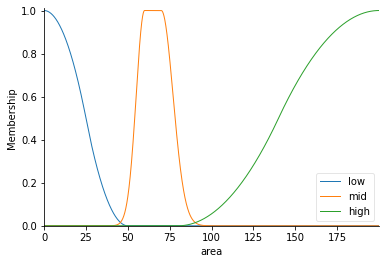

In [5]:
area = ctrl.Antecedent(np.arange(0, 200, 0.1), "area")

area['low'] = skf.zmf(area.universe, 0, 50)
area["mid"] = skf.gauss2mf(area.universe, 60, 5, 70, 7)
area["high"] = skf.smf(area.universe, 80, 200)

area.view()

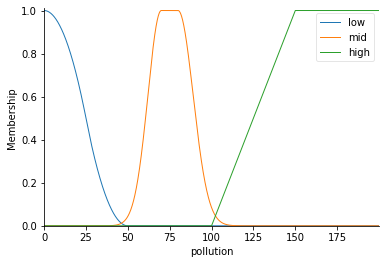

In [41]:
pollution = ctrl.Antecedent(np.arange(0, 200, 0.1), "pollution")

pollution['low'] = skf.zmf(pollution.universe, 0, 50)
pollution["mid"] = skf.gauss2mf(pollution.universe, 70, 8, 80, 9)
pollution["high"] = trapezoid(pollution.universe, 100, 150, 200, 200)

pollution.view()

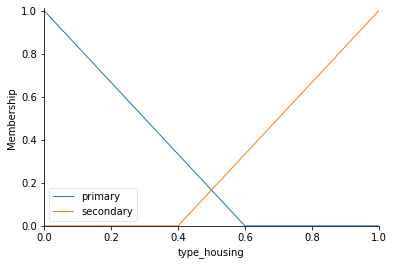

In [21]:
type_housing = ctrl.Antecedent(np.arange(0, 1.1, 0.1), "type_housing")

type_housing['primary'] = trapezoid(type_housing.universe, -1, 0, 0, 0.6)
type_housing['secondary'] = trapezoid(type_housing.universe, 0.4, 1, 1, 2)

type_housing.view()

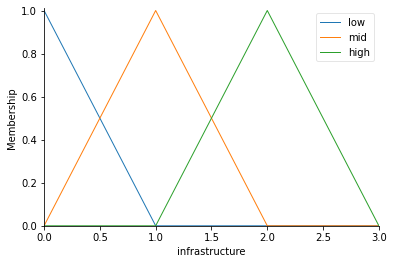

In [13]:
infrastructure = ctrl.Antecedent(np.arange(0, 4, 1), "infrastructure")

infrastructure['low'] = trapezoid(infrastructure.universe, -1, 0, 0, 1)
infrastructure['mid'] = trapezoid(infrastructure.universe, 0, 1, 1, 2)
infrastructure['high'] = trapezoid(infrastructure.universe, 1, 2, 2, 3)

infrastructure.view()

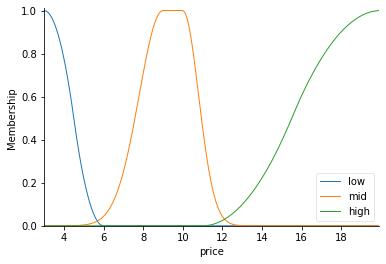

In [20]:
price = ctrl.Consequent(np.arange(3, 20, 0.1), "price")

price['low'] = skf.zmf(price.universe, 3, 6)
price['mid'] = skf.gauss2mf(price.universe, 9, 1.2, 10, 0.8)
price['high'] = skf.smf(price.universe, 11, 20)

price.view()

In [22]:
rule1 = ctrl.Rule(area['mid'] | pollution['mid'] | infrastructure['mid'] | type_housing['primary'], 
                  [price['low']])
rule2 = ctrl.Rule(area['low'] | pollution['mid'] | infrastructure['mid'] | type_housing['primary'], 
                  [price['low']])
rule3 = ctrl.Rule(area['high'] | pollution['mid'] | infrastructure['mid'] | type_housing['primary'], 
                  [price['mid']])
rule4 = ctrl.Rule(area['high'] | pollution['low'] | infrastructure['mid'] | type_housing['primary'], 
                  [price['mid']])
rule5 = ctrl.Rule(area['high'] | pollution['high'] | infrastructure['mid'] | type_housing['primary'], 
                  [price['mid']])
rule6 = ctrl.Rule(area['low'] | pollution['low'] | infrastructure['mid'] | type_housing['primary'], 
                  [price['low']])
rule7 = ctrl.Rule(area['low'] | pollution['high'] | infrastructure['mid'] | type_housing['primary'], 
                  [price['low']])
rule8 = ctrl.Rule(area['low'] | pollution['low'] | infrastructure['low'] | type_housing['primary'], 
                  [price['low']])
rule9 = ctrl.Rule(area['low'] | pollution['low'] | infrastructure['high'] | type_housing['primary'], 
                  [price['low']])
rule10 = ctrl.Rule(area['high'] | pollution['low'] | infrastructure['high'] | type_housing['primary'], 
                  [price['high']])
rule11 = ctrl.Rule(area['high'] | pollution['high'] | infrastructure['high'] | type_housing['primary'], 
                  [price['mid']])
rule12 = ctrl.Rule(area['low'] | pollution['high'] | infrastructure['low'] | type_housing['primary'], 
                  [price['low']])
rule13 = ctrl.Rule(area['low'] | pollution['high'] | infrastructure['high'] | type_housing['primary'], 
                  [price['low']])
rule14 = ctrl.Rule(area['low'] | pollution['low'] | infrastructure['low'] | type_housing['primary'], 
                  [price['low']])
rule15 = ctrl.Rule(area['high'] | pollution['mid'] | infrastructure['low'] | type_housing['primary'], 
                  [price['low']])
rule16 = ctrl.Rule(area['high'] | pollution['mid'] | infrastructure['high'] | type_housing['primary'], 
                  [price['mid']])
rule17 = ctrl.Rule(area['mid'] | pollution['mid'] | infrastructure['high'] | type_housing['primary'], 
                  [price['mid']])
rule18 = ctrl.Rule(area['mid'] | pollution['mid'] | infrastructure['mid'] | type_housing['secondary'], 
                  [price['mid']])
rule19 = ctrl.Rule(area['low'] | pollution['mid'] | infrastructure['mid'] | type_housing['secondary'], 
                  [price['mid']])
rule20 = ctrl.Rule(area['high'] | pollution['mid'] | infrastructure['mid'] | type_housing['secondary'], 
                  [price['high']])
rule21 = ctrl.Rule(area['high'] | pollution['low'] | infrastructure['mid'] | type_housing['secondary'], 
                  [price['high']])
rule22 = ctrl.Rule(area['high'] | pollution['high'] | infrastructure['mid'] | type_housing['secondary'], 
                  [price['high']])
rule23 = ctrl.Rule(area['low'] | pollution['low'] | infrastructure['mid'] | type_housing['secondary'], 
                  [price['mid']])
rule24 = ctrl.Rule(area['low'] | pollution['high'] | infrastructure['mid'] | type_housing['secondary'], 
                  [price['mid']])
rule25 = ctrl.Rule(area['low'] | pollution['low'] | infrastructure['low'] | type_housing['secondary'], 
                  [price['mid']])
rule26 = ctrl.Rule(area['low'] | pollution['low'] | infrastructure['high'] | type_housing['secondary'], 
                  [price['mid']])
rule27 = ctrl.Rule(area['high'] | pollution['low'] | infrastructure['high'] | type_housing['secondary'], 
                  [price['high']])
rule28 = ctrl.Rule(area['high'] | pollution['high'] | infrastructure['high'] | type_housing['secondary'], 
                  [price['high']])
rule29 = ctrl.Rule(area['low'] | pollution['high'] | infrastructure['low'] | type_housing['secondary'], 
                  [price['mid']])
rule30 = ctrl.Rule(area['low'] | pollution['high'] | infrastructure['high'] | type_housing['secondary'], 
                  [price['mid']])
rule31 = ctrl.Rule(area['low'] | pollution['low'] | infrastructure['low'] | type_housing['secondary'], 
                  [price['mid']])
rule32 = ctrl.Rule(area['high'] | pollution['mid'] | infrastructure['low'] | type_housing['secondary'], 
                  [price['high']])
rule33 = ctrl.Rule(area['high'] | pollution['mid'] | infrastructure['high'] | type_housing['secondary'], 
                  [price['high']])
rule34 = ctrl.Rule(area['mid'] | pollution['mid'] | infrastructure['high'] | type_housing['secondary'], 
                  [price['high']])

In [23]:
rules_base = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
              rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19,
              rule20, rule21, rule23, rule24, rule25, rule26, rule28,
              rule29, rule31, rule32, rule33, rule34]

mark_ctrl = ctrl.ControlSystem(rules_base)
marking = ctrl.ControlSystemSimulation(mark_ctrl)

12.155609922510292


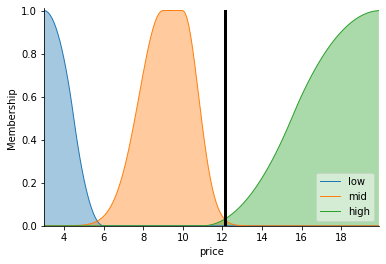

In [24]:
#1
marking.input['area'] = 0
marking.input['pollution'] = 0
marking.input['infrastructure'] = 0
marking.input['type_housing'] = 0
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

12.155609922510292


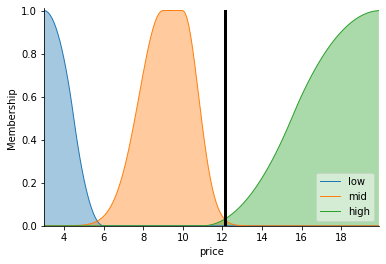

In [25]:
#2
marking.input['area'] = 0
marking.input['pollution'] = 0
marking.input['infrastructure'] = 0
marking.input['type_housing'] = 1
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

12.155609922510292


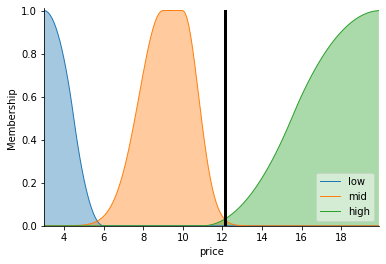

In [26]:
#2
marking.input['area'] = 110
marking.input['pollution'] = 0
marking.input['infrastructure'] = 0
marking.input['type_housing'] = 1
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

13.370655101951147


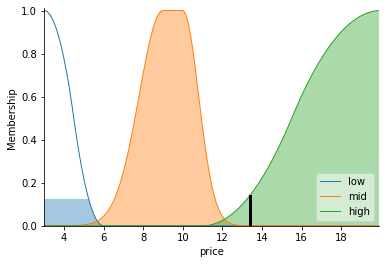

In [36]:
#4
marking.input['area'] = 110
marking.input['pollution'] = 50
marking.input['infrastructure'] = 3
marking.input['type_housing'] = 2
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

13.370655101951147


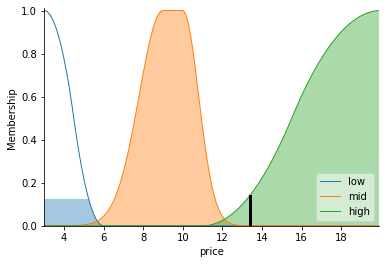

In [35]:
#5
marking.input['area'] = 110
marking.input['pollution'] = 50
marking.input['infrastructure'] = 3
marking.input['type_housing'] = 1
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

12.155609922510292


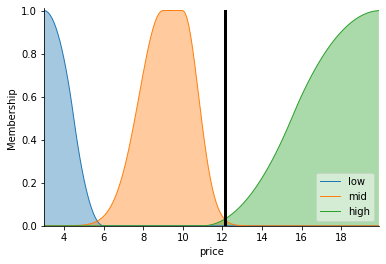

In [37]:
#6
marking.input['area'] = 20
marking.input['pollution'] = 50
marking.input['infrastructure'] = 0
marking.input['type_housing'] = 1
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

12.155609922510292


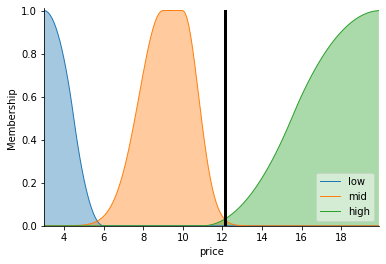

In [34]:
#7
marking.input['area'] = 200
marking.input['pollution'] = 200
marking.input['infrastructure'] = 2
marking.input['type_housing'] = 1
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

12.155609922510292


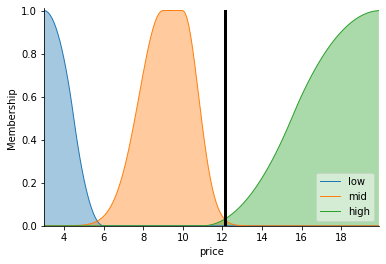

In [38]:
#8
marking.input['area'] = 0
marking.input['pollution'] = 200
marking.input['infrastructure'] = 2
marking.input['type_housing'] = 1
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

12.155609922510292


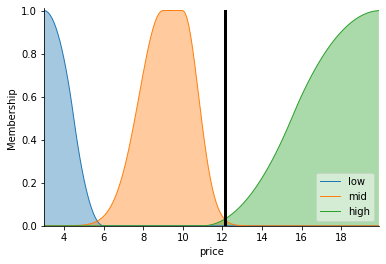

In [33]:
#9
marking.input['area'] = 130
marking.input['pollution'] = 0
marking.input['infrastructure'] = 1
marking.input['type_housing'] = 2
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

12.155609922510292


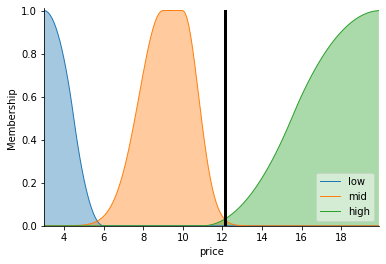

In [39]:
#10
marking.input['area'] = 40
marking.input['pollution'] = 17
marking.input['infrastructure'] = 1
marking.input['type_housing'] = 1
marking.compute()

print(marking.output['price'])
price.view(sim=marking)

12.159362743895493


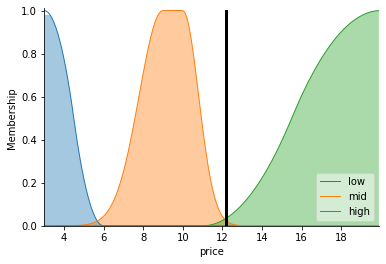

In [40]:
#11
marking.input['area'] = 85
marking.input['pollution'] = 190
marking.input['infrastructure'] = 3
marking.input['type_housing'] = 2
marking.compute()

print(marking.output['price'])
price.view(sim=marking)